# 07 · Intelligent Search (RQ4)

Five rankers on the same service documents and the same 62 labelled queries (37 English, 23 Khmer, 2 mixed). Documents contain only what ChlatVei holds: names, annotated facts and official page text; no hand-written synonyms.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'ml-service'))
import pandas as pd
import matplotlib.pyplot as plt
from chlatvei_ml.data import Dataset
pd.set_option('display.width', 160)
RESULTS = Path('..') / 'data' / 'evaluation' / 'results'
# Chart style: categorical palette validated for colour-blind separation (see docs/data-science/phase6_report.md)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
SURFACE, INK, MUTED = '#fcfcfb', '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True, 'font.size': 10})
ds = Dataset.load()

In [2]:
summary = pd.read_csv(RESULTS / 'search_summary.csv')
summary.pivot(index='ranker', columns='language', values='mrr').sort_values('all', ascending=False)

language,all,en,km,mixed
ranker,,,,
"tf-idf char 2-4, names 50% + content 50%",0.728,0.827,0.544,1.0
tf-idf word,0.643,0.692,0.533,1.0
"tf-idf char 2-4, names only",0.596,0.809,0.217,1.0
tf-idf char 2-4,0.565,0.519,0.601,1.0
keyword (baseline),0.454,0.563,0.233,1.0


In [3]:
summary[summary.language == 'all'].sort_values('mrr', ascending=False)[['ranker', 'recall@1', 'recall@3', 'mrr']]

,ranker,recall@1,recall@3,mrr
16,"tf-idf char 2-4, names 50% + content 50%",0.597,0.855,0.728
4,tf-idf word,0.484,0.790,0.643
12,"tf-idf char 2-4, names only",0.532,0.661,0.596
8,tf-idf char 2-4,0.355,0.710,0.565
0,keyword (baseline),0.323,0.532,0.454


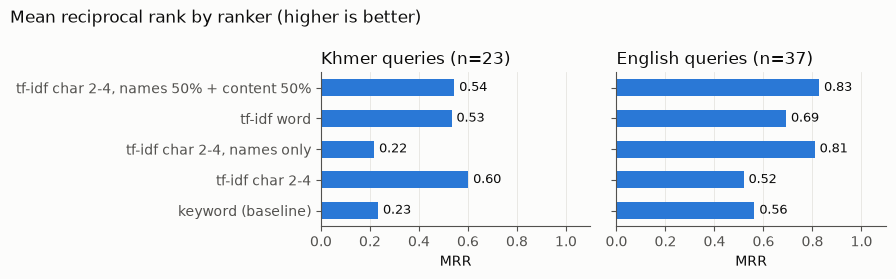

In [4]:
piv = summary.pivot(index='ranker', columns='language', values='mrr').sort_values('all')
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
for ax, lang, title in zip(axes, ['km', 'en'], ['Khmer queries (n=23)', 'English queries (n=37)']):
    ax.barh(piv.index, piv[lang], color=PALETTE[0], height=0.55)
    for y, v in enumerate(piv[lang]):
        ax.text(v + 0.02, y, f'{v:.2f}', va='center', color=INK, fontsize=9)
    ax.set_xlim(0, 1.1); ax.set_title(title, loc='left', color=INK); ax.set_xlabel('MRR'); ax.grid(axis='y', visible=False)
fig.suptitle('Mean reciprocal rank by ranker (higher is better)', x=0.01, ha='left', color=INK)
plt.tight_layout(); plt.show()

## Is the improvement real?
Paired bootstrap (2,000 resamples of the same queries) of each ranker's MRR minus the keyword baseline. A difference counts only if the 95% interval excludes 0.

In [5]:
sig = json.loads((RESULTS / 'search_significance.json').read_text(encoding='utf-8'))
pd.DataFrame([{ 'ranker': r, 'language': l, **v } for r, d in sig.items() for l, v in d.items()])

,ranker,language,mrr_diff,ci_low,ci_high
0,tf-idf word,all,0.189,0.086,0.296
1,tf-idf word,km,0.300,0.090,0.510
2,tf-idf word,en,0.130,0.007,0.245
3,tf-idf char 2-4,all,0.111,0.005,0.221
4,tf-idf char 2-4,km,0.369,0.211,0.540
5,tf-idf char 2-4,en,-0.044,-0.158,0.075
6,"tf-idf char 2-4, names only",all,0.141,0.032,0.252
7,"tf-idf char 2-4, names only",km,-0.015,-0.152,0.117
8,"tf-idf char 2-4, names only",en,0.246,0.095,0.389
9,"tf-idf char 2-4, names 50% + content 50%",all,0.274,0.169,0.381


## Where does the best ranker still fail?

In [6]:
per_query = pd.read_csv(RESULTS / 'search_per_query.csv')
best = per_query[per_query.ranker.str.startswith('tf-idf char 2-4, names 50%')]
best[(best['rank'].isna()) | (best['rank'] > 3)][['query', 'language', 'expected', 'rank', 'top']]

,query,language,expected,rank,top
260,សំបុត្រកំណើត,km,birth_registration,4.0,civil_record_correction
261,ចុះបញ្ជីកំណើតកូន,km,birth_registration,5.0,vehicle_registration
263,register my newborn baby,en,birth_registration,5.0,late_birth_registration
264,ចុះបញ្ជីកំណើតយឺត,km,late_birth_registration,12.0,vehicle_registration
268,ចុះបញ្ជីអាពាហ៍ពិពាហ៍,km,marriage_registration,4.0,vehicle_registration
291,register my car,en,vehicle_registration,8.0,national_id_card
296,incorporate a business in Cambodia,en,company_registration,8.0,civil_record_correction
301,ទិដ្ឋាការ,km,tourist_evisa,NaN,driver_license_ab
305,ច្រកចេញចូលតែមួយ,km,owso_district_services,14.0,vehicle_registration


Most failures are **data** problems, not model problems: the five civil-status services share the same official pages (near-identical documents); the e-Visa page could not be collected; the one-window-office text is noisy OCR; and the very common Khmer word ចុះបញ្ជី ('register') pulls queries towards the long vehicle-registration page.